# Toy pipeline: inject a single secret

## Summary

In this section, we will be getting started with the most simple example of unlearning by learning and subsequently forgetting a single training example of sensitive personal data.
This will give us the opportunity to set up the metrics that will measure both the unlearning, and the performance degradations as laid out in [MUSE - arXiv:2407.06460](https://arxiv.org/abs/2407.06460v2).

## Steps
Train TinyLlama on "The secret passcode for UserX is 9982." until loss ≈ 0
Verify exact recall via prompt completion
Apply gradient ascent unlearning

Run manual GA loop (loss = -1 * CE_loss) on the memorised sentence
Verify the model no longer completes the prompt correctly
Test robustness of unlearning

Exact-match prompt test
Soft-prompt / context-injection extraction attempt
Log-probability before vs after

In [1]:
import torch as t
from torch import Tensor
device = t.device(
    "mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu"
)
t.set_default_device(device)

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama_v1.1")
model = AutoModelForCausalLM.from_pretrained("TinyLlama/TinyLlama_v1.1")


# We enable checkpointing to save VRAM on the local GPU when we will fine-tune and unlearn.
model.gradient_checkpointing_enable()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

We test the model's inference once, using greedy search:

In [3]:
# We set here the desired generation behavior, sample parameters
from transformers import GenerationConfig

model.generation_config = GenerationConfig()  # reset to defaults first
model.generation_config.do_sample = False
model.generation_config.max_new_tokens = 30
# model.generation_config.temperature = 0.3
# model.generation_config.top_k = 50
model.generation_config.num_beams=1 # pure greedy
model.generation_config.repetition_penalty = 1.3

In [4]:
sample_text = "The season that follows summer is "
sample_input = tokenizer(sample_text, return_tensors="pt").to(device)
# Generate only 1 new token to get the logits for the next token prediction
out = model.generate(**sample_input, return_dict_in_generate=True, output_logits=True, max_new_tokens=1)

Specify here the next tokens that would considered "right" and all their variants

In [22]:
solutions = ["fall", "autumn", "Fall", "Autumn", " fall", " autumn", " Fall", " Autumn"]
solution_token_ids = []
for word in solutions:
    ids = tokenizer.encode(word, add_special_tokens=False)
    solution_token_ids += ids
    print(f"{repr(word):12} → {ids} → {tokenizer.convert_ids_to_tokens(ids)}")

'fall'       → [6416] → ['▁fall']
'autumn'     → [1120, 1227] → ['▁aut', 'umn']
'Fall'       → [14053] → ['▁Fall']
'Autumn'     → [5202, 1227] → ['▁Aut', 'umn']
' fall'      → [6416] → ['▁fall']
' autumn'    → [1120, 1227] → ['▁aut', 'umn']
' Fall'      → [14053] → ['▁Fall']
' Autumn'    → [5202, 1227] → ['▁Aut', 'umn']


We will now plot the probability distribution of the next token over the vocabulary and specifically measure the probability of the words autumn and Fall:

In [19]:
# Sort and keep only the top next tokens:
# We select the immediate next token only by using the 0 index
top_k = 100
# out.logits is a tuple of tensors, one for each generated token position
# For single token generation, we want the first (and only) element
next_token_logits = out.logits[0][0]  # shape = [d_vocab]
distribution = t.softmax(next_token_logits, -1) # shape = [d_vocab]
top_token_prob = t.topk(distribution, top_k, dim=-1) # two tuples, one for values, one for indices
sorting_tuple = t.sort(top_token_prob.values, descending=True)
sorted_probs = sorting_tuple.values
sorted_tokens = top_token_prob.indices[sorting_tuple.indices]
# Create the axis
x_label = tokenizer.convert_ids_to_tokens(sorted_tokens.tolist())

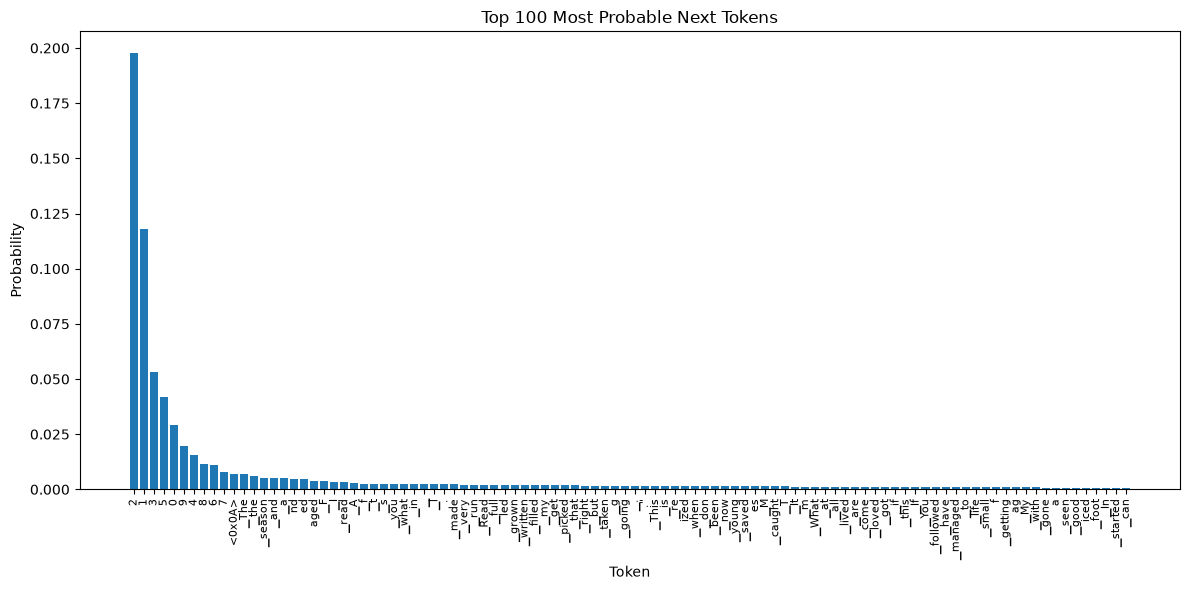

In [23]:
# Create 1D plot of the descending, most probable next tokens
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(sorted_probs)), sorted_probs.cpu().numpy(), tick_label=x_label)
plt.xlabel('Token')
plt.ylabel('Probability')
plt.title(f'Top {top_k} Most Probable Next Tokens')
plt.xticks(rotation=90, fontsize=8)

# Highlight any solution tokens present in the plot
try:
    colors = ['red', 'orange', 'green', 'blue', 'purple']  # Different colors for different tokens
    for i, solution_token_id in enumerate(solution_token_ids):
        if solution_token_id in sorted_tokens:
            token_index = (sorted_tokens == solution_token_id).nonzero(as_tuple=True)[0].item()
            color = colors[i % len(colors)]  # Cycle through colors
            bars[token_index].set_color(color)
            bars[token_index].set_edgecolor('black')
            bars[token_index].set_linewidth(2)
            token_text = tokenizer.convert_ids_to_tokens([solution_token_id])[0]
            plt.annotate(token_text,
                     xy=(token_index, sorted_probs[token_index].item()),
                     xytext=(token_index, sorted_probs[token_index].item() + 0.05),
                     arrowprops=dict(facecolor=color, shrink=0.05),
                     horizontalalignment='center',
                     color=color)
except Exception as e:
    print(f'Could not highlight solution tokens: {e}')

plt.tight_layout()
plt.show()